# Nucleation

## Parameters

In [1]:
coupling: float = 1.0
gamma: float = 0.5
nsmall: int = 2
nqubits: int = 12

## Setup

### Imports

In [2]:
import functools


import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')

import matplotlib as mpl
import numpy as np
import scipy

import cirq

### Helper functions

In [3]:
def get_tfim(
    nqubits: int,
    coupling: float = coupling,
    gamma: float = gamma,
) -> cirq.PauliSum:
    qubits = cirq.LineQubit.range(nqubits)
    return coupling * sum(
        cirq.Z.on(qubits[i]) * cirq.Z.on(qubits[i + 1]) for i in range(nqubits - 1)
    ) - gamma * sum(cirq.X.on(qubits[i]) for i in range(nqubits))

In [4]:
class ExpZZ(cirq.Gate):
    def __init__(self, theta):
        super(ExpZZ, self)
        self.theta = theta

    def _num_qubits_(self):
        return 2

    def _unitary_(self):
        return scipy.linalg.expm(
            -1j * np.kron(cirq.unitary(cirq.Z), cirq.unitary(cirq.Z)) * self.theta
        )

    # def _decompose_(self, qubits):
    #     a, b = qubits
    #     yield cirq.CNOT(a, b)
    #     yield cirq.rz(self.theta).on(b)
    #     yield cirq.CNOT(a, b)

    def _circuit_diagram_info_(self, args):
        return f"ExpZZ({self.theta:.3f})", f"ExpZZ({self.theta:.3f})"


def trotter_step(time: float, nqubits: int, s: float = 1.0) -> cirq.OP_TREE:
    qubits = cirq.LineQubit.range(-nqubits // 2, nqubits // 2, 1)
    new_bonds = (0, nqubits - 2)
    scale = lambda i: s if i in new_bonds else 1.0
    yield cirq.Moment(
        ExpZZ(coupling * time * scale(i)).on(qubits[i], qubits[i + 1])
        for i in range(0, nqubits - 1, 2)
    )
    yield cirq.Moment(
        ExpZZ(coupling * time * scale(i)).on(qubits[i], qubits[i + 1])
        for i in range(1, nqubits - 1, 2)
    )
    yield cirq.Moment(cirq.X.on(q) ** (-gamma * time * 2 / np.pi) for q in qubits)

## Nucleation

### Bounds

In [5]:
def schedule(u):
    return np.sin(np.pi * u / 2) ** 2

def get_nucleation_tfim(
    nqubits: int,
    s: float,
    coupling: float = coupling,
    gamma: float = gamma,
) -> cirq.PauliSum:
    """TFIM for one nucleation stage, with the two new edge bonds scaled by s."""
    qubits = cirq.LineQubit.range(nqubits)
    ham = get_tfim(nqubits=nqubits, coupling=coupling, gamma=gamma)

    # get_tfim contains both edge bonds with coefficient coupling.
    # Correct their coefficients from coupling -> s * coupling.
    edge_bonds = (
        cirq.Z.on(qubits[0]) * cirq.Z.on(qubits[1])
        + cirq.Z.on(qubits[-2]) * cirq.Z.on(qubits[-1])
    )
    return ham + (s - 1.0) * coupling * edge_bonds

In [6]:
def get_nucleation_tfim_linear_operator(
    nqubits: int,
    s: float,
    coupling: float = coupling,
    gamma: float = gamma,
):
    """Sparse LinearOperator for get_nucleation_tfim(nqubits, s)."""
    dim = 2**nqubits
    basis = np.arange(dim, dtype=np.int64)

    # Diagonal ZZ contribution in the computational basis.
    diagonal = np.zeros(dim, dtype=float)
    for i in range(nqubits - 1):
        # Cirq orders q(0), q(1), ... from most- to least-significant bit.
        bit_i = nqubits - 1 - i
        bit_j = nqubits - 1 - (i + 1)
        zi = 1 - 2 * ((basis >> bit_i) & 1)
        zj = 1 - 2 * ((basis >> bit_j) & 1)
        bond_scale = s if i in (0, nqubits - 2) else 1.0
        diagonal += coupling * bond_scale * zi * zj

    # X_i flips one computational-basis bit.
    flipped = [
        basis ^ (1 << (nqubits - 1 - i))
        for i in range(nqubits)
    ]

    def matvec(vector):
        result = diagonal * vector
        for flipped_i in flipped:
            result = result - gamma * vector[flipped_i]
        return result

    return scipy.sparse.linalg.LinearOperator(
        shape=(dim, dim),
        matvec=matvec,
        dtype=np.float64,
    )


# Verify the sparse representation against get_tfim / Cirq on a small example.
_test_n = 4
_test_s = 0.37
_test_ham = get_nucleation_tfim(_test_n, _test_s).matrix()
_test_op = get_nucleation_tfim_linear_operator(_test_n, _test_s)
_test_vec = np.random.default_rng(0).standard_normal(2**_test_n)
assert np.allclose(_test_ham @ _test_vec, _test_op @ _test_vec)

In [7]:
def instantaneous_gap(nqubits: int, u: float) -> float:
    """E_1(u) - E_0(u) for one nucleation stage."""
    ham = get_nucleation_tfim_linear_operator(
        nqubits=nqubits,
        s=schedule(u),
    )
    evals = scipy.sparse.linalg.eigsh(
        ham,
        k=2,
        which="SA",
        return_eigenvectors=False,
        tol=1e-11,
        maxiter=20_000,
    )
    evals = np.sort(evals)
    return float(evals[1] - evals[0])


def minimum_gap_for_stage(nqubits: int, ngrid: int = 101):
    """Grid scan plus local refinement of min_u Delta_n(u)."""
    u_grid = np.linspace(0.0, 1.0, ngrid)
    gaps = np.array([instantaneous_gap(nqubits, u) for u in u_grid])
    imin = int(np.argmin(gaps))

    # Refine around the best grid point, while retaining the endpoints as candidates.
    lo = u_grid[max(imin - 1, 0)]
    hi = u_grid[min(imin + 1, ngrid - 1)]
    candidates = [(u_grid[imin], gaps[imin])]

    if hi > lo:
        result = scipy.optimize.minimize_scalar(
            lambda u: instantaneous_gap(nqubits, u),
            bounds=(lo, hi),
            method="bounded",
            options={"xatol": 1e-8},
        )
        candidates.append((float(result.x), float(result.fun)))
        candidates.append((lo, instantaneous_gap(nqubits, lo)))
        candidates.append((hi, instantaneous_gap(nqubits, hi)))

    u_min, delta_min = min(candidates, key=lambda item: item[1])
    return u_min, delta_min, u_grid, gaps

In [8]:
nucleation_sizes = range(nsmall + 2, nqubits + 1, 2)

gap_data = {}
stage_minima = {}

for n in nucleation_sizes:
    u_min, delta_min_n, u_grid, gaps = minimum_gap_for_stage(n)
    gap_data[n] = (u_grid, gaps)
    stage_minima[n] = (u_min, delta_min_n)
    print(
        f"n = {n:2d}: Delta_min = {delta_min_n:.12g} "
        f"at u = {u_min:.8f}, s = {schedule(u_min):.8f}"
    )

n_gap_min = min(stage_minima, key=lambda n: stage_minima[n][1])
u_gap_min, Delta_min = stage_minima[n_gap_min]

print()
print(f"Global Delta_min = {Delta_min:.12g}")
print(f"attained for n = {n_gap_min}, u = {u_gap_min:.8f}, s = {schedule(u_gap_min):.8f}")

n =  4: Delta_min = 0.0947875877431 at u = 1.00000000, s = 1.00000000
n =  6: Delta_min = 0.0234618855552 at u = 0.99999975, s = 1.00000000
n =  8: Delta_min = 0.00585988920759 at u = 0.99999962, s = 1.00000000
n = 10: Delta_min = 0.0014648538783 at u = 1.00000000, s = 1.00000000
n = 12: Delta_min = 0.000366211128478 at u = 1.00000000, s = 1.00000000

Global Delta_min = 0.000366211128478
attained for n = 12, u = 1.00000000, s = 1.00000000


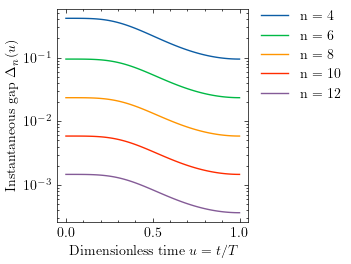

In [9]:
fig, ax = plt.subplots(constrained_layout=True)

for n, (u_grid, gaps) in gap_data.items():
    ax.semilogy(u_grid, gaps, "-", ms=5, mec="black", label=f"n = {n}")

ax.set_xlabel(r"Dimensionless time $u=t/T$")
ax.set_ylabel(r"Instantaneous gap $\Delta_n(u)$")
ax.legend(ncol=1, bbox_to_anchor=(1, 1.05))
# plt.savefig(f"gap_tfim_J_{coupling}_h_{gamma}.pdf")

In [10]:
# Desired infidelity for a single nucleation step
epsilon = 1e-3

# Adiabatic bound on T
J = coupling
h = gamma
C_ad = (
    2 * np.pi * abs(J) / Delta_min**2
    + 7 * np.pi**2 * J**2 / (2 * Delta_min**3)
)
T_bound = C_ad / np.sqrt(epsilon)

# N Trotter bound.
Lambda_1 = np.pi * abs(J)

# Use the largest nucleation stage for a bound valid for every stage.
n = nqubits
n_bonds = n - 1
Lambda_2 = 4 * abs(J * h) * n_bonds

# Allocate error between adiabatic and digitization errors
T = 2 * C_ad / np.sqrt(epsilon)
eta = np.sqrt(epsilon) / 2
N_bound = np.ceil(
    (
        T * Lambda_1 / 4
        + T**2 * Lambda_2 / 2
    )
    / eta
).astype(int)

print(f"T >= {T:.6e}")
print(f"N Trotter (per nucleation stage) >= {N_bound:.6e}")

# There are (nqubits - nsmall)/2 nucleation stages.
n_stages = (nqubits - nsmall) // 2
N_total = n_stages * N_bound
print(f"N Trotter (total) >= {N_total:.6e}")

T >= 4.448690e+13
N Trotter (per nucleation stage) >= 9.223372e+18
N Trotter (total) >= 9.223372e+18


/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_14507/2684729493.py:30: RuntimeWarning: invalid value encountered in cast
  ).astype(int)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_14507/2684729493.py:37: RuntimeWarning: overflow encountered in scalar multiply
  N_total = n_stages * N_bound


### Compute ground state for nucleus

In [11]:
ham = get_tfim(nsmall).matrix()
evals, evecs = np.linalg.eigh(ham)
ground_state = evecs[:, 0]
assert np.allclose(ham @ ground_state, evals[0] * ground_state)
ground_state

array([-0.27059805+0.j, -0.65328148+0.j, -0.65328148+0.j, -0.27059805+0.j])

### Nucleate

In [12]:
ntrotter_vals = np.arange(20, 400 + 1, 20)
tvals = np.arange(1, 40 + 1, 2)

In [13]:
ham_large = get_tfim(nqubits=nqubits).matrix()
evals, evecs = np.linalg.eigh(ham_large)
true_ground_state = evecs[:, 0]
assert np.allclose(ham_large @ true_ground_state, evals[0] * true_ground_state)

/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_14507/730873186.py:4: RuntimeWarning: divide by zero encountered in matmul
  assert np.allclose(ham_large @ true_ground_state, evals[0] * true_ground_state)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_14507/730873186.py:4: RuntimeWarning: overflow encountered in matmul
  assert np.allclose(ham_large @ true_ground_state, evals[0] * true_ground_state)
/var/folders/z9/f3y13fq11gl5lnryg82b_ks40000gn/T/ipykernel_14507/730873186.py:4: RuntimeWarning: invalid value encountered in matmul
  assert np.allclose(ham_large @ true_ground_state, evals[0] * true_ground_state)


In [14]:
istate = functools.reduce(
    np.kron,
    [cirq.KET_PLUS.state_vector()] * ((nqubits - nsmall) // 2) + [ground_state] + [cirq.KET_PLUS.state_vector()] * ((nqubits - nsmall) // 2),
).astype(np.complex64)
ioverlap = np.abs(true_ground_state.conj().T @ istate) ** 2
ioverlap

np.float64(0.022301254770149662)

In [15]:
overlaps = np.zeros(shape=(len(ntrotter_vals), len(tvals)))
twoq_gates = np.zeros(shape=(len(ntrotter_vals), len(tvals)))

for i, ntrotter in enumerate(ntrotter_vals):
    for j, time in enumerate(tvals):
        print(f"Status: {ntrotter=}, {time=}")
        circuit = cirq.Circuit()

        for nqubits in range(4, nqubits + 1, 2):
            for k in range(ntrotter):
                s = np.sin(0.5 * np.pi * (k + 0.5) / ntrotter) ** 2
                circuit.append(trotter_step(time / ntrotter, nqubits=nqubits, s=s))

        print(f"{len(circuit)} moments, {len(list(circuit.all_operations()))} operations")

        fstate = cirq.Simulator().simulate(circuit, initial_state=istate).final_state_vector
        overlap = np.abs(true_ground_state.conj().T @ fstate) ** 2
        print("Overlap with ground state:", overlap)
        overlaps[i, j] = overlap
        twoq_gates[i, j] = len([op for op in circuit.all_operations() if len(op.qubits) == 2])

Status: ntrotter=np.int64(20), time=np.int64(1)
300 moments, 1500 operations
Overlap with ground state: 0.10681592996542678
Status: ntrotter=np.int64(20), time=np.int64(3)
300 moments, 1500 operations
Overlap with ground state: 0.24842453569828826
Status: ntrotter=np.int64(20), time=np.int64(5)
300 moments, 1500 operations
Overlap with ground state: 0.5406645222188092
Status: ntrotter=np.int64(20), time=np.int64(7)
300 moments, 1500 operations
Overlap with ground state: 0.7088178752038338
Status: ntrotter=np.int64(20), time=np.int64(9)
300 moments, 1500 operations
Overlap with ground state: 0.7677996966876803
Status: ntrotter=np.int64(20), time=np.int64(11)
300 moments, 1500 operations
Overlap with ground state: 0.7393126859927152
Status: ntrotter=np.int64(20), time=np.int64(13)
300 moments, 1500 operations
Overlap with ground state: 0.630087856961612
Status: ntrotter=np.int64(20), time=np.int64(15)
300 moments, 1500 operations
Overlap with ground state: 0.5203159078465021
Status: ntro

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/cirq/sim/state_vector_simulator.py:131: UserWarning: final state vector's norm=np.float32(0.9996443) is too far from 1, 0.00035572052001953125 > 0.0003452669770922512.skipping renormalization
  warnings.warn(


Overlap with ground state: 0.9872167199344442
Status: ntrotter=np.int64(280), time=np.int64(35)
4200 moments, 21000 operations
Overlap with ground state: 0.9863157698797174
Status: ntrotter=np.int64(280), time=np.int64(37)
4200 moments, 21000 operations
Overlap with ground state: 0.984491281741017
Status: ntrotter=np.int64(280), time=np.int64(39)
4200 moments, 21000 operations
Overlap with ground state: 0.9833806632757617
Status: ntrotter=np.int64(300), time=np.int64(1)
4500 moments, 22500 operations
Overlap with ground state: 0.10617237980381536
Status: ntrotter=np.int64(300), time=np.int64(3)
4500 moments, 22500 operations
Overlap with ground state: 0.2664489948022289
Status: ntrotter=np.int64(300), time=np.int64(5)
4500 moments, 22500 operations
Overlap with ground state: 0.5677338007711663
Status: ntrotter=np.int64(300), time=np.int64(7)
4500 moments, 22500 operations
Overlap with ground state: 0.8321239266830838
Status: ntrotter=np.int64(300), time=np.int64(9)
4500 moments, 22500 

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/cirq/sim/state_vector_simulator.py:131: UserWarning: final state vector's norm=np.float32(0.99963427) is too far from 1, 0.0003657341003417969 > 0.0003452669770922512.skipping renormalization
  warnings.warn(


Overlap with ground state: 0.9953975340146372
Status: ntrotter=np.int64(300), time=np.int64(19)
4500 moments, 22500 operations
Overlap with ground state: 0.995411702804844
Status: ntrotter=np.int64(300), time=np.int64(21)
4500 moments, 22500 operations
Overlap with ground state: 0.9946676824178039
Status: ntrotter=np.int64(300), time=np.int64(23)
4500 moments, 22500 operations
Overlap with ground state: 0.9949104994034097
Status: ntrotter=np.int64(300), time=np.int64(25)
4500 moments, 22500 operations
Overlap with ground state: 0.9933160124580224
Status: ntrotter=np.int64(300), time=np.int64(27)
4500 moments, 22500 operations
Overlap with ground state: 0.9923361592860696
Status: ntrotter=np.int64(300), time=np.int64(29)
4500 moments, 22500 operations
Overlap with ground state: 0.9922644893420558
Status: ntrotter=np.int64(300), time=np.int64(31)
4500 moments, 22500 operations
Overlap with ground state: 0.9898665309362932
Status: ntrotter=np.int64(300), time=np.int64(33)
4500 moments, 22

...

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/cirq/sim/state_vector_simulator.py:131: UserWarning: final state vector's norm=np.float32(0.999624) is too far from 1, 0.00037598609924316406 > 0.0003452669770922512.skipping renormalization
  warnings.warn(


Overlap with ground state: 0.9941048145943291
Status: ntrotter=np.int64(400), time=np.int64(17)
6000 moments, 30000 operations


/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/cirq/sim/state_vector_simulator.py:131: UserWarning: final state vector's norm=np.float32(0.99961114) is too far from 1, 0.00038886070251464844 > 0.0003452669770922512.skipping renormalization
  warnings.warn(


Overlap with ground state: 0.9964027410498832
Status: ntrotter=np.int64(400), time=np.int64(19)
6000 moments, 30000 operations
Overlap with ground state: 0.9970019029498053
Status: ntrotter=np.int64(400), time=np.int64(21)
6000 moments, 30000 operations
Overlap with ground state: 0.996661753227592
Status: ntrotter=np.int64(400), time=np.int64(23)
6000 moments, 30000 operations
Overlap with ground state: 0.9970211601639649
Status: ntrotter=np.int64(400), time=np.int64(25)
6000 moments, 30000 operations
Overlap with ground state: 0.9960438693193349
Status: ntrotter=np.int64(400), time=np.int64(27)
6000 moments, 30000 operations
Overlap with ground state: 0.9955297118586368
Status: ntrotter=np.int64(400), time=np.int64(29)
6000 moments, 30000 operations
Overlap with ground state: 0.9956518756845893
Status: ntrotter=np.int64(400), time=np.int64(31)
6000 moments, 30000 operations
Overlap with ground state: 0.9941299778721293
Status: ntrotter=np.int64(400), time=np.int64(33)
6000 moments, 30

/Users/ryan/prof/work/nucleate/repo/envnucleate/lib/python3.10/site-packages/cirq/sim/state_vector_simulator.py:131: UserWarning: final state vector's norm=np.float32(0.99958825) is too far from 1, 0.00041174888610839844 > 0.0003452669770922512.skipping renormalization
  warnings.warn(


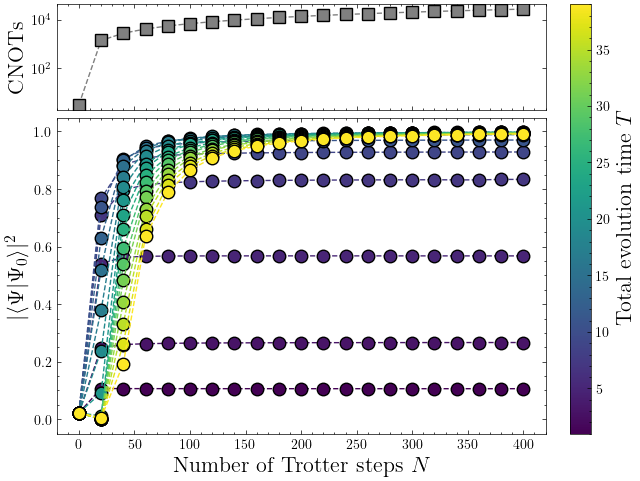

In [16]:
fs = 16

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    height_ratios=[0.3333333, 1],
    constrained_layout=True,
    figsize=(6.4, 4.8)
)

# Top panel
axes[0].semilogy(
    [0] + list(ntrotter_vals),
    [3] + list(2 * twoq_gates[:, 0]),
    "--s",
    color="grey",
    mec="black",
    ms=8,
)
axes[0].set_ylabel("CNOTs", fontsize=fs)

# Colormap for T
cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(vmin=min(tvals), vmax=max(tvals))

# Bottom panel
for i, T in enumerate(tvals):
    axes[1].plot(
        [0] + list(ntrotter_vals),
        [ioverlap] + list(overlaps[:, i]),
        "--o",
        color=cmap(norm(T)),
        mec="black",
        ms=9,
    )

axes[1].set_xlabel("Number of Trotter steps $N$", fontsize=fs)
axes[1].set_ylabel(r"$|\langle \Psi | \Psi_0 \rangle|^2$", fontsize=fs)

# Colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=axes, shrink=1.0)
cbar.set_label(r"Total evolution time $T$", fontsize=fs)

# plt.savefig("nucleation-1D-tfim-v2.pdf")